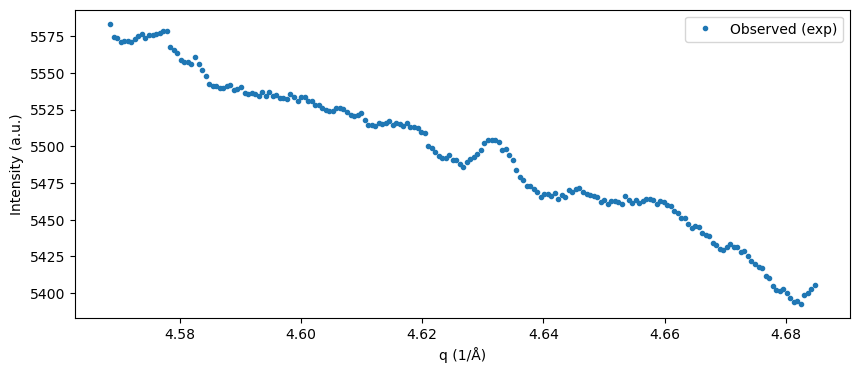

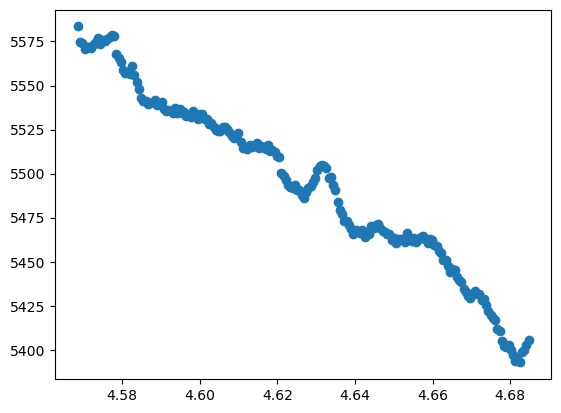

5000 iters; elapsed 55.30074620246887
10000 iters; elapsed 110.50664210319519
15000 iters; elapsed 165.34020328521729
20000 iters; elapsed 221.02163195610046
25000 iters; elapsed 275.90584111213684
30000 iters; elapsed 331.88002347946167
35000 iters; elapsed 388.9002950191498
40000 iters; elapsed 447.5876135826111
45000 iters; elapsed 506.85038328170776
50000 iters; elapsed 566.1264786720276
Total elapsed: 566.1425023078918
おおむね0.2から0.8の間に収まっていれば成功。


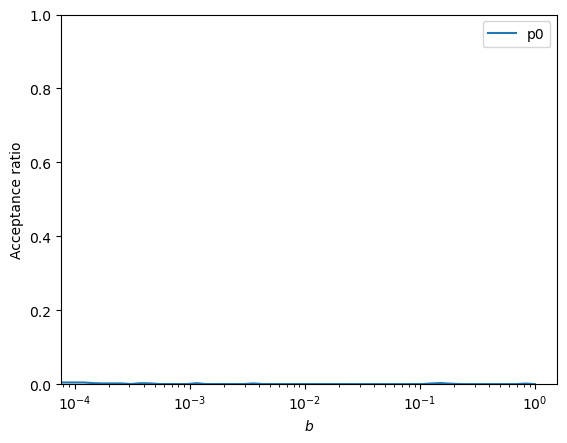

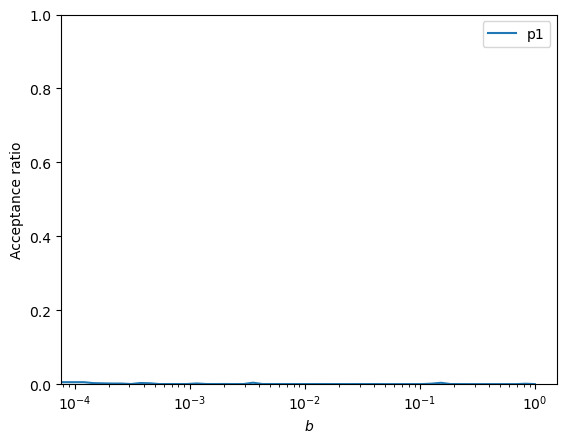

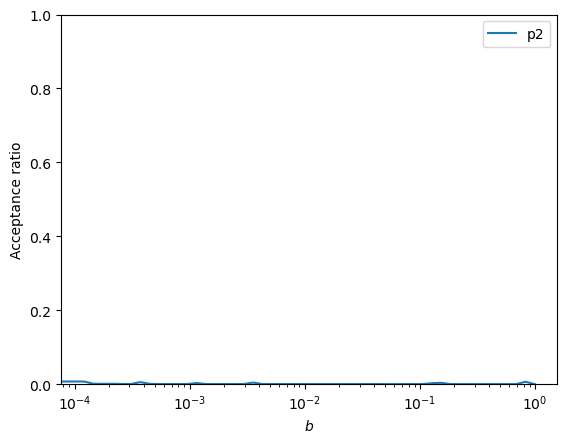

収束するまでの焼きなまし区間(burn_in)が十分か確認する。


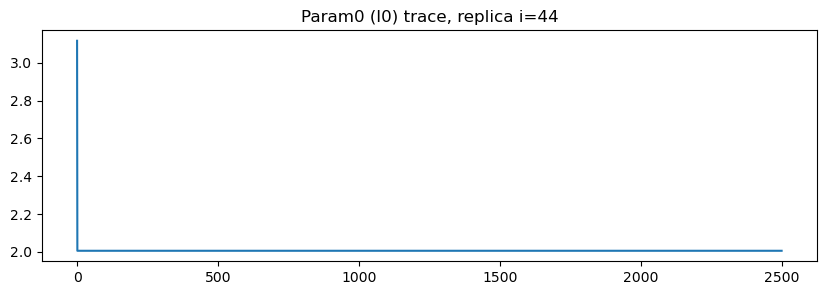

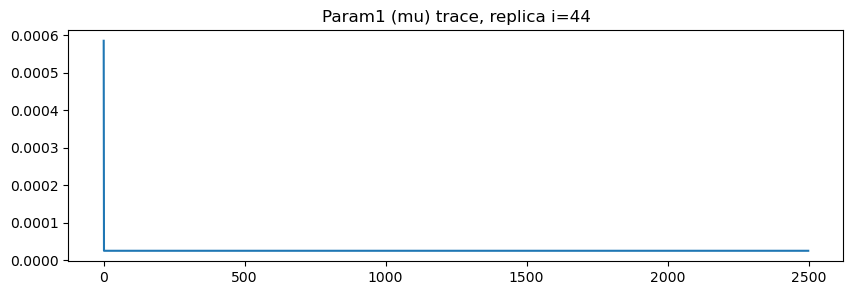

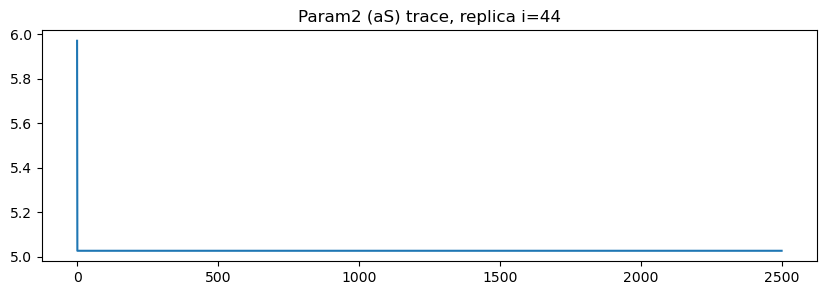

最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認) 0.0


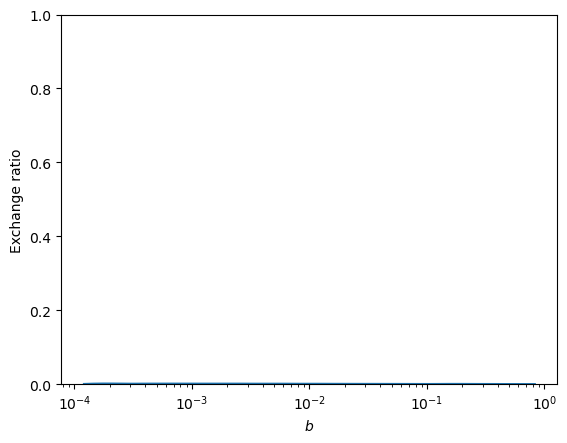

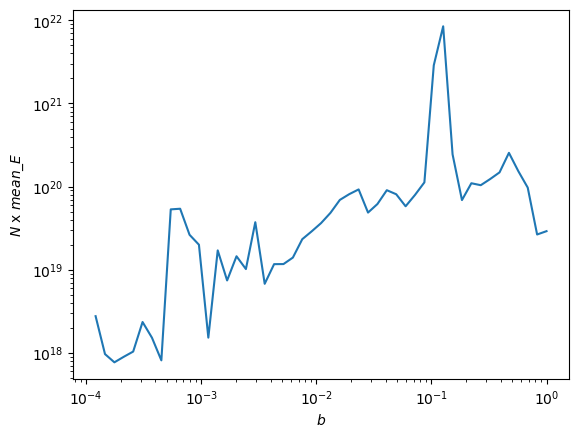

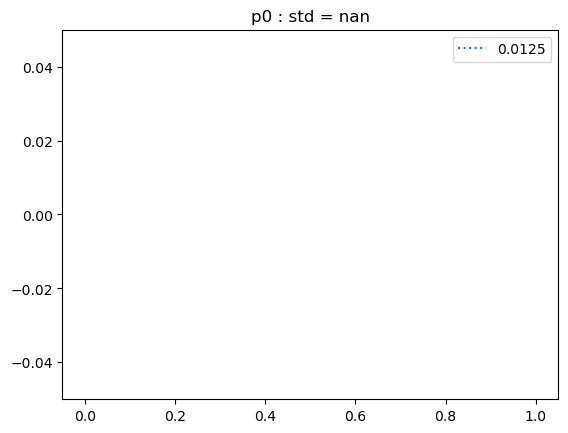

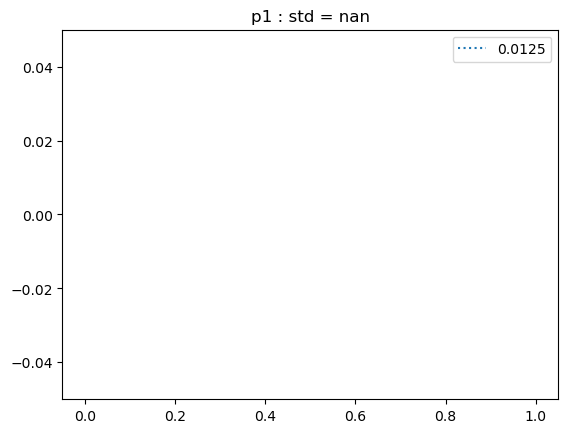

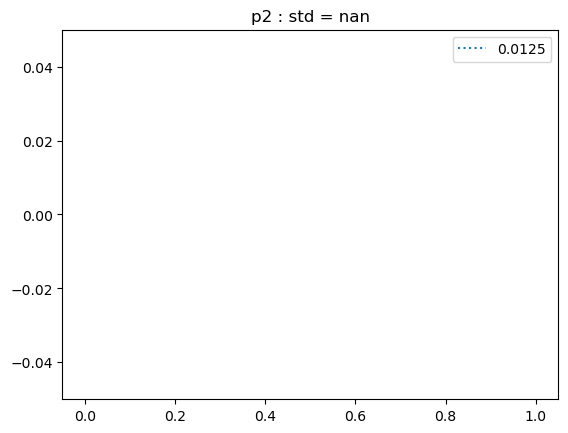

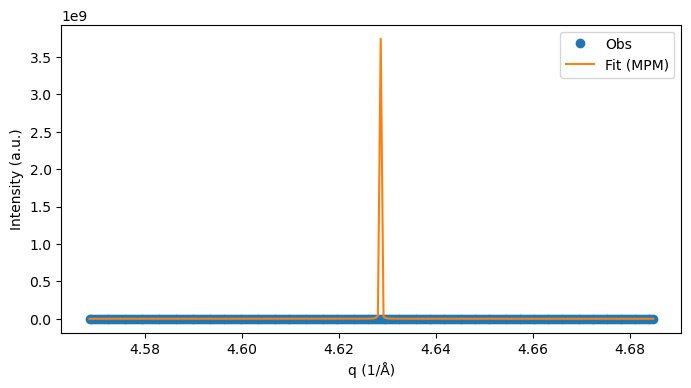

array([2.17820751e+00, 1.02681375e-04, 5.22532711e+00])

In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[16]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import itertools
import math
from matplotlib.colors import LogNorm
import time
#from numpy.random import *
import numexpr as ne
from IPython.display import clear_output
import os
import warnings
warnings.filterwarnings('ignore')
#from google.colab import drive
#drive.mount('/content/drive')

# In[1]:
import numpy as np

# ===== CTR Model #04 (closed-form) =====
# I(q) = 10**I0 * | sum_{n=0}^{NS} exp(-mu*n) * exp(i*q*aS*n)  +  1/(sqrt(2) * sin(q*a/2)) |^2
E_KEV_FIXED = 8.0    # fixed
A_FIXED     = 5.43   # Å, fixed
NS_FIXED    = 128971 # fixed

def _geom_series_complex(r, N):
    """Closed form of sum_{n=0}^{N} r^n for complex r (vectorized)."""
    eps = 1e-12
    near1 = np.abs(r-1) < eps
    out = np.empty_like(r, dtype=np.complex128)
    out[near1]  = (N+1) + 0j
    out[~near1] = (1 - np.power(r[~near1], N+1)) / (1 - r[~near1])
    return out

def CTRmodel04(q_data, I0, mu, aS, a=A_FIXED, NS=NS_FIXED):
    # r = exp(-mu) * exp(i q aS)
    r = np.exp(-mu) * np.exp(1j * q_data * aS)
    exp_sum = _geom_series_complex(r, NS)
    # substrate term
    exp_sum = exp_sum + 1.0 / (np.sqrt(2.0) * np.sin(q_data * a / 2.0))
    Iq_ = (10.0**I0) * np.abs(exp_sum)**2
    return Iq_

# 并行温度各副本的向量化前向模型
def CTR04fit(q, _p_):
    # _p_ shape: (num_temp, 3) with params [I0, mu, aS]
    I0 = _p_[:,0].reshape(num_temp,1)
    mu = _p_[:,1].reshape(num_temp,1)
    aS = _p_[:,2].reshape(num_temp,1)
    return CTRmodel04(q, I0, mu, aS)

# In[2]:
# （保留单元编号占位；原 axbfit 被 CTR04fit 替代）

# In[6]:
# ===== 读取实验数据并 2θ→q =====
import pandas as pd, numpy as np, math, os, re

data_path = "data-2025-0822by akai/Si_TEOS_2thome.dat"

def load_si_teos(path):
    # 宽松解析（文件含日文头部；数据行为逗号分隔）
    with open(path, "rb") as f:
        raw = f.read()
    txt = raw.decode("cp932", errors="ignore")
    rows = []
    for ln in txt.splitlines():
        if re.match(r"^\s*[-+]?\d+(\.\d+)?\s*,", ln):
            parts = [p.strip() for p in ln.split(",")]
            try:
                vals = [float(p.replace("E+", "e+").replace("E-", "e-")) for p in parts]
                rows.append(vals)
            except:
                pass
    df = pd.DataFrame(rows)
    # 典型为 [2theta_deg, monitor?, intensity, norm]
    if df.shape[1] >= 3:
        df = df.iloc[:, [0,2]].rename(columns={0:"two_theta_deg", 2:"intensity"})
    else:
        df = df.iloc[:, :2]
        df.columns = ["two_theta_deg", "intensity"]
    return df

df = load_si_teos(data_path)

# E=8 keV -> λ(Å)
lambda_ang = 12.39842 / E_KEV_FIXED
theta_rad  = np.deg2rad(df["two_theta_deg"].values / 2.0)
q = (4.0*np.pi/lambda_ang) * np.sin(theta_rad)   # [1/Å]
I_obs = df["intensity"].values.astype(np.float64)

# 避开模型奇点 sin(q*a/2)=0
mask = np.isfinite(I_obs) & np.isfinite(q)
mask &= (np.abs(np.sin(q * A_FIXED / 2.0)) > 1e-6)

x = q[mask].reshape(-1)   # 用 x, y 与原 Notebook 对齐命名
y = I_obs[mask].reshape(-1)

plt.figure(figsize=(10,4))
plt.plot(x, y, ".", label="Observed (exp)")
plt.xlabel("q (1/Å)"); plt.ylabel("Intensity (a.u.)")
plt.legend(); plt.show()

# In[7]:
x

# In[8]:
x

# In[9]:
# （保留占位）

# In[10]:
y

# In[11]:
y

# In[12]:
# （保留占位）

# In[13]:
# 解析するデータのプロット
plt.plot(x,y,"o")
plt.show()

# In[14]:
# （保留占位）

# In[3]:
# メトロポリス法によるパラメータ更新
# （此处保留单元号；实际更新在主循环中实现）

# In[4]:
# 擬似フォークト関数（原样保留；与本拟合无关）
def psV(x,mu,w_l,w_g,A,x0):
    y = A*(mu*2/np.pi*w_l/(4*(x-x0)**2+w_l**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w_g*np.exp(-4*np.log(2)/w_g**2*(x-x0)**2))
    return y

# In[5]:
def psVfit(x,_p_):
    A1   = _p_[:,0].reshape(num_temp,1)
    mu1  = _p_[:,1].reshape(num_temp,1)
    w_l1 = _p_[:,2].reshape(num_temp,1)
    w_g1 = _p_[:,3].reshape(num_temp,1)
    x1   = _p_[:,4].reshape(num_temp,1)
    A2   = _p_[:,5].reshape(num_temp,1)
    mu2  = _p_[:,6].reshape(num_temp,1)
    w_l2 = _p_[:,7].reshape(num_temp,1)
    w_g2 = _p_[:,8].reshape(num_temp,1)
    x2   = _p_[:,9].reshape(num_temp,1)
    y = psV(x,mu1,w_l1,w_g1,A1,x1) + psV(x,mu2,w_l2,w_g2,A2,x2)
    return y

# In[15]:
# ===== 并行温度 MCMC (Metropolis + 邻链交换) =====
import time, os
np.random.seed(1)

# 拟合参数：I0, mu, aS
num_para = 3
# 先验范围（可按数据微调）
_p_min_ = np.array([  2.0, 1e-7, 5.00])  # I0, mu, aS
_p_max_ = np.array([  6.0, 1e-3, 6.00])

# 噪声估计（稳健）
y_med      = np.median(y)
_sigma_R_  = max(1e-6, 0.5*np.median(np.abs(y - y_med)))
sigma_R    = _sigma_R_
sigma_R_sim = max(1e-6, 0.2*np.std(y))  # 仅备查

# 逆温度表
num_temp = 50
temp = np.logspace(-4, 0, num_temp)  # β from 1e-4..1
temp[0] = 0  # prior-only 链

# 步长随温度缩放
_st = np.array([0.05, 1e-5, 5e-3])   # I0, mu, aS
steps = np.zeros((num_temp, num_para))
for j in range(num_para):
    alpha, d = 5.0, 1.0
    steps[:, j] = np.where(temp <= 1/alpha, _st[j], _st[j]/(alpha*temp)**d)
steps[0,:] = _st

# 初值：从先验采样
ini_pri = 1
if ini_pri==1:
    _p_ = _p_min_ + (_p_max_ - _p_min_) * np.random.rand(num_temp, num_para)
else:
    _p_ = np.tile((_p_min_ + _p_max_)/2, (num_temp,1))

# 负对数似然/先验/能量
def neg_log_like(p, beta, q=x, y=y, sigma=sigma_R):
    yhat = CTRmodel04(q, p[0], p[1], p[2])
    resid = (y - yhat)
    return beta * (0.5/(sigma**2)) * np.sum(resid*resid)

def neg_log_prior(p):
    if np.any(p < _p_min_) or np.any(p > _p_max_):
        return np.inf
    return 0.0

def energy(p, beta):
    return neg_log_prior(p) + neg_log_like(p, beta)

# 采样设置
cycle = 50000
burn_in_length = 10000
n = x.size

_dir_ = "CTR04fit_2025_0827"
os.makedirs(_dir_, exist_ok=True)

ratio_p   = np.zeros((num_temp, num_para)) # 每参数接受计数
ratio_temp= np.zeros(num_temp)             # 交换接受计数
mean_E    = np.zeros(num_temp)             # 能量累计

# 轨迹
rslt_p   = [np.array([]) for _ in range(num_para)]   # 最低温链轨迹
_rslt_p0_= [np.array([]) for _ in range(num_temp)]
_rslt_p1_= [np.array([]) for _ in range(num_temp)]
_rslt_p2_= [np.array([]) for _ in range(num_temp)]

# 初始能量
_E_ = np.zeros(num_temp)
for j in range(num_temp):
    _E_[j] = energy(_p_[j], temp[j])

st = time.time()
thin = 20

for i in range(cycle):
    # 随机扫描参数更新
    for _param_idx in np.random.permutation(num_para):
        for j in range(1, num_temp):  # j=0 用 prior-only
            cur  = _p_[j].copy()
            prop = cur.copy()
            prop[_param_idx] = cur[_param_idx] + np.random.normal(scale=steps[j,_param_idx])
            # 反射边界，保持在先验范围内
            low, high = _p_min_[_param_idx], _p_max_[_param_idx]
            if prop[_param_idx] < low or prop[_param_idx] > high:
                prop[_param_idx] = np.clip(low + (low - prop[_param_idx]) if prop[_param_idx]<low else high - (prop[_param_idx]-high), low, high)

            e_cur  = _E_[j]
            e_prop = energy(prop, temp[j])
            if np.isfinite(e_prop) and (np.random.rand() < np.exp(-(e_prop - e_cur))):
                _p_[j] = prop
                _E_[j] = e_prop
                ratio_p[j,_param_idx] += 1

        # j=0:prior-only
        _p_[0,_param_idx] = _p_min_[_param_idx] + (_p_max_[_param_idx]-_p_min_[_param_idx]) * np.random.rand()
        _E_[0] = energy(_p_[0], temp[0])

    # 邻链交换
    if (i % 2) == 0:
        pairs = [(j, j+1) for j in range(1, num_temp-1, 2)]
    else:
        pairs = [(j, j+1) for j in range(2, num_temp-1, 2)]
    for j, k in pairs:
        e_jj = _E_[j]; e_kk = _E_[k]
        e_jk = energy(_p_[j], temp[k]); e_kj = energy(_p_[k], temp[j])
        if np.log(np.random.rand()) < -(e_jk + e_kj - e_jj - e_kk):
            _p_[j], _p_[k] = _p_[k].copy(), _p_[j].copy()
            _E_[j], _E_[k] = _E_[k], _E_[j]
            ratio_temp[j] += 1; ratio_temp[k] += 1

    # 记录
    mean_E += _E_
    if (i % thin) == 0:
        for j in range(num_temp):
            _rslt_p0_[j] = np.append(_rslt_p0_[j], _p_[j,0])
            _rslt_p1_[j] = np.append(_rslt_p1_[j], _p_[j,1])
            _rslt_p2_[j] = np.append(_rslt_p2_[j], _p_[j,2])
        for pidx in range(num_para):
            rslt_p[pidx] = np.append(rslt_p[pidx], _p_[-1,pidx])

    # 周期性保存
    if ((i+1) % 5000) == 0:
        print(i+1, "iters; elapsed", time.time()-st)
        np.save(_dir_+"/ratio_p.npy", ratio_p)
        np.save(_dir_+"/ratio_temp.npy", ratio_temp)
        np.save(_dir_+"/mean_E.npy", mean_E)
        np.save(_dir_+"/_rslt_p0_.npy", _rslt_p0_)
        np.save(_dir_+"/_rslt_p1_.npy", _rslt_p1_)
        np.save(_dir_+"/_rslt_p2_.npy", _rslt_p2_)
        np.save(_dir_+"/_E_.npy", _E_)
        np.save(_dir_+"/_p_all_.npy", _p_)
        np.save(_dir_+"/_mean_E_.npy", mean_E)
        np.save(_dir_+"/_ratio_p_.npy", ratio_p)

# 最终保存
np.save(_dir_+"/ratio_p.npy", ratio_p)
np.save(_dir_+"/ratio_temp.npy", ratio_temp)
np.save(_dir_+"/mean_E.npy", mean_E)
np.save(_dir_+"/_rslt_p0_.npy", _rslt_p0_)
np.save(_dir_+"/_rslt_p1_.npy", _rslt_p1_)
np.save(_dir_+"/_rslt_p2_.npy", _rslt_p2_)
np.save(_dir_+"/_E_.npy", _E_)
np.save(_dir_+"/_p_all_.npy", _p_)
np.save(_dir_+"/_mean_E_.npy", mean_E)
np.save(_dir_+"/_ratio_p_.npy", ratio_p)
print("Total elapsed:", time.time()-st)

# In[16]:
_dir_

# In[17]:
# （保留占位）

# In[18]:
# ===== 採択率のプロット =====
ratio_p = np.load(_dir_+"/ratio_p.npy")
print("おおむね0.2から0.8の間に収まっていれば成功。")
for i in range(num_para):
    plt.plot(temp, ratio_p[:,i]/(cycle-burn_in_length), label="p{}".format(i))
    plt.xscale("log"); plt.ylim(0,1)
    plt.xlabel("$b$"); plt.ylabel("Acceptance ratio")
    plt.legend(); plt.show()

# In[19]:
# ===== 各パラメータの採択履歴をプロット =====
print("収束するまでの焼きなまし区間(burn_in)が十分か確認する。")
i = 44 # 確認したいレプリカのインデックス（0..49）

_rslt_p0_ = np.load(_dir_+"/_rslt_p0_.npy", allow_pickle=True)
_rslt_p1_ = np.load(_dir_+"/_rslt_p1_.npy", allow_pickle=True)
_rslt_p2_ = np.load(_dir_+"/_rslt_p2_.npy", allow_pickle=True)

plt.figure(figsize=(10,3)); plt.plot(_rslt_p0_[i]); plt.title("Param0 (I0) trace, replica i={}".format(i)); plt.show()
plt.figure(figsize=(10,3)); plt.plot(_rslt_p1_[i]); plt.title("Param1 (mu) trace, replica i={}".format(i)); plt.show()
plt.figure(figsize=(10,3)); plt.plot(_rslt_p2_[i]); plt.title("Param2 (aS) trace, replica i={}".format(i)); plt.show()

# In[20]:
# ===== レプリカ交換率とmean_Eのプロット =====
ratio_temp = np.load(_dir_+"/ratio_temp.npy")
mean_E     = np.load(_dir_+"/mean_E.npy")

print("最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認)", ratio_temp[0]/((cycle-burn_in_length)/2))
_ratio_temp_       = np.zeros((num_temp,2)); _ratio_temp_[:,0] = temp; _ratio_temp_[:,1] = ratio_temp/((cycle-burn_in_length)/2)
_mean_E_           = np.zeros((num_temp,2)); _mean_E_[:,0]     = temp; _mean_E_[:,1]     = mean_E/(cycle-burn_in_length)

plt.plot(temp[1:num_temp-1], ratio_temp[1:num_temp-1]/((cycle-burn_in_length)/2))
plt.xscale("log"); plt.xlabel("$b$"); plt.ylabel("Exchange ratio"); plt.ylim(0,1); plt.show()

plt.plot(temp[1:num_temp], n*mean_E[1:num_temp]/(cycle-burn_in_length))
plt.xlabel("$b$"); plt.xscale("log"); plt.yscale("log"); plt.ylabel("$N$ x $mean$_$E$"); plt.show()

# In[21]:
# （保留占位）

# In[22]:
# ===== 事後確率分布をプロット =====
# 最低温レプリカを使用
i = num_temp-1
_pp_MPM_ = np.zeros(num_para)
for j in range(num_para):
    arr    = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    series = (arr[i])[burn_in_length::]
    plt.title("p{} : std = {:.4f}".format(j, np.std(series)))
    plt.hist(series, bins=40)
    _pp_hist_ = np.histogram(series, bins=40)
    _pp_MPM_[j] = ((_pp_hist_[1])[np.argmax(_pp_hist_[0])+1] + (_pp_hist_[1])[np.argmax(_pp_hist_[0])]) / 2.0
    plt.vlines(_pp_MPM_[j], 0, 1.1*np.max(_pp_hist_[0]), linestyle="dotted", label="{:.4f}".format(_pp_MPM_[j]))
    plt.ylim(0, 1.1*np.max(_pp_hist_[0])); plt.legend(); plt.show()

# In[23]:
# ===== パラメータごとの事後確率分布の最大値(MPM)によるフィッティング結果 =====
# 用最低温のサンプルの中央値を MPM 近似として利用
_p_all_   = np.load(_dir_+"/_p_all_.npy")
_pp_MPM_  = np.median(_p_all_[-1:,:], axis=0)
I0, mu, aS = _pp_MPM_

y_fit = CTRmodel04(x, I0, mu, aS)

plt.figure(figsize=(8,4))
plt.plot(x, y, "o", label="Obs")
plt.plot(x, y_fit, "-", label="Fit (MPM)")
plt.xlabel("q (1/Å)"); plt.ylabel("Intensity (a.u.)")

# 可选：限制显示窗口（例如 q in [0.6, 1.7]）
Q_WINDOW = None  # (0.6, 1.7)
if Q_WINDOW:
    plt.xlim(Q_WINDOW)

plt.legend(); plt.show()

# In[24]:
_pp_MPM_
